In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utility.my_colors import palette_dark
from data.local.hamann_erq_desi_idxs import valid_sdss_names

In [3]:
sdss_current_stats_path = "data/local/sdss_current_best_measurements.csv"
desi_current_stats_path = "data/local/desi_current_best_measurements.csv"

sdss_df = pd.read_csv(sdss_current_stats_path,index_col=0)
# sdss_df = sdss_df.drop(columns=['absorption_relevant', 'rew', 'fwhm', 'kt80'])
sdss_df = sdss_df.drop(columns=['absorption_relevant'])
sdss_df = sdss_df.rename(columns={"z_dr12":"redshift"})
sdss_df = sdss_df[sdss_df["sdss_name"].isin(valid_sdss_names)]
sdss_df = sdss_df.assign(survey="boss")

desi_df = pd.read_csv(desi_current_stats_path,index_col=0)
desi_df = desi_df.assign(survey="desi")

stats_long = pd.concat([desi_df,sdss_df])
stats_long = stats_long[['sdss_name', 'survey', 'redshift', 'rew', 'fit_rew', 'fwhm', 'kt80', 'my_fwhm', 'my_rew', 'my_kt80', 'rew_abs_diff', 'fwhm_abs_diff', 'kt80_abs_diff', 'rew_rel_diff', 'fwhm_rel_diff', 'kt80_rel_diff']].set_index(["sdss_name","survey"]).sort_values("sdss_name")

stats_short = desi_df.merge(sdss_df,on="sdss_name",suffixes=("_desi","_sdss"))
stats_short = stats_short.drop(columns=["survey_desi","survey_sdss"])
stats_short = stats_short.rename(columns={"rew_desi":"rew","kt80_desi":"kt80","fwhm_desi":"fwhm"})

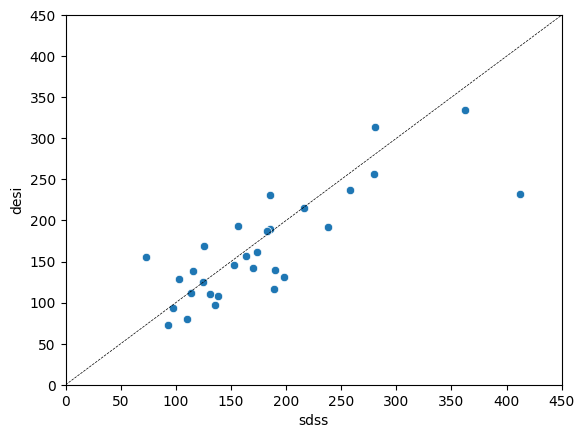

In [4]:
lim = 450

sns.scatterplot(data=stats_short,x="my_rew_sdss",y="my_rew_desi")

plt.plot([0,lim],[0,lim],color="black",linestyle="--",linewidth=0.5)

plt.xlim(0,lim)
plt.ylim(0,lim)
plt.xlabel("sdss")
plt.ylabel("desi")

plt.show()

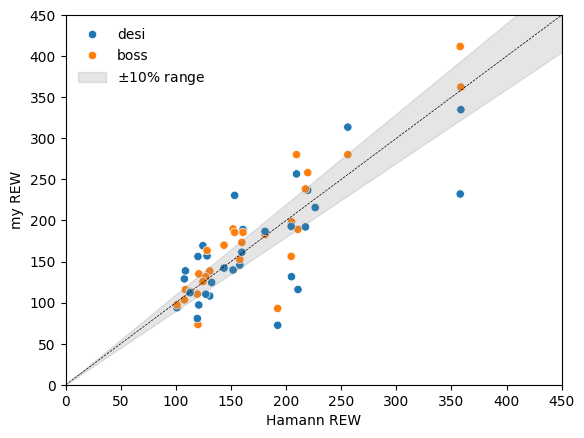

In [5]:
lim = 450

sns.scatterplot(data=stats_long,x="rew",y="my_rew",hue="survey")

plt.plot([0,lim],[0,lim],color="black",linestyle="--",linewidth=0.5)
plt.fill_between([0,lim],[0,lim-lim*0.1],[0,lim+lim*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

plt.xlim(0,lim)
plt.ylim(0,lim)
plt.xlabel("Hamann REW")
plt.ylabel("my REW")
plt.legend(frameon=False)

plt.show()

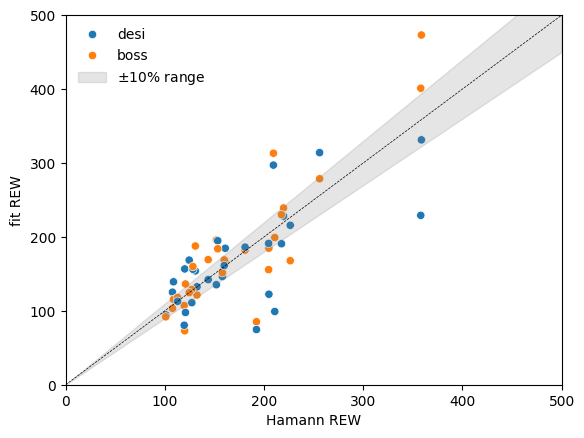

In [6]:
lim = 500

sns.scatterplot(data=stats_long,x="rew",y="fit_rew",hue="survey")

plt.plot([0,lim],[0,lim],color="black",linestyle="--",linewidth=0.5)
plt.fill_between([0,lim],[0,lim-lim*0.1],[0,lim+lim*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

plt.xlim(0,lim)
plt.ylim(0,lim)
plt.xlabel("Hamann REW")
plt.ylabel("fit REW")
plt.legend(frameon=False)

plt.show()

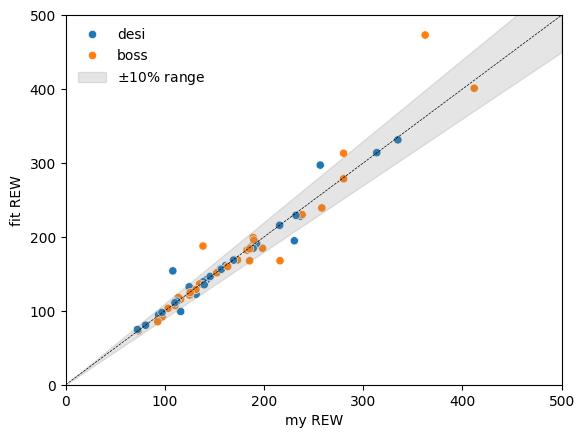

In [7]:
lim = 500

sns.scatterplot(data=stats_long,x="my_rew",y="fit_rew",hue="survey")

plt.plot([0,lim],[0,lim],color="black",linestyle="--",linewidth=0.5)
plt.fill_between([0,lim],[0,lim-lim*0.1],[0,lim+lim*0.1],alpha=0.2,label=r"$\pm$10% range",color="gray")

plt.xlim(0,lim)
plt.ylim(0,lim)
plt.xlabel("my REW")
plt.ylabel("fit REW")
plt.legend(frameon=False)

plt.show()